<a href="https://colab.research.google.com/github/mariiam36/EML_MontesinosOlivaOuardi/blob/main/Entornos_Complejos/Metodos_Tabulares/Sarsa_CliffWalking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLE - Práctica 1 parte 2**
***Máster en Inteligencia Artificial - Universidad de Murcia***

**Hecho por**: 
- Jorge Montesinos Bravo
- Manuel Oliva Marín
- Mariam Ouardi Bennane

**Profesor**: Luis Daniel Hernández Molinero

**Fecha**: 15/03/2026

# **SARSA con Políticas epsilon-soft**

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de SARSA con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "CliffWalking", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando obstáculos.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "CliffWalking"**:
Se carga el entorno "CliffWalking".

- **Funciones para Mostrar los Resultados**: Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.

##### **Código de la Instalación e Importación**
----

In [ ]:
#@title Clonamos el repositorio
!git clone https://github.com/mariiam36/EML_MontesinosOlivaOuardi.git
%cd EML_MontesinosOlivaOuardi/Entornos_Complejos/Metodos_Tabulares

In [ ]:
#@title Instalamos librería Gymnasium
%%capture
%pip install 'gym[box2d]==0.20.0'

In [ ]:
#@title Importamos librerías
from environments.cliff import make_cliff_env
from algorithms.sarsa import SARSA
from utils.plotting import plot_curve
from utils.fix_seed import fix_seed

In [ ]:
#@title Importamos el entorno cliff walking
NUM_EPISODES = 5000
SEED = 100
fix_seed(SEED)
env = make_cliff_env(seed=SEED)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

# Definimos las acciones
UP, RIGHT, DOWN, LEFT = 0,1,2,3

Número de estados: 48
Número de acciones: 4


## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
  - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
  - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
  - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo SARSA**
  - Se implementa el algoritmo SARSA como método de control basado en diferencias temporales (TD).
  - Se trata de un método "on-policy", ya que la actualización se realiza utilizando la misma política epsilon-greedy con la que el agente interactúa con el entorno.
  - La actualización de los valores Q se realiza de forma incremental en cada paso del episodio, utilizando una tasa de aprendizaje constante $\alpha$.
  - La actualización se basa en la transición $(s, a, r, s', a')$, empleando el valor estimado de la siguiente acción seleccionada por la política.

## **3. Experimentación**

- En esta sección, el algoritmo SARSA con política epsilon (con decaimiento) se ejecuta para el entorno de Cliff Walking.

- Se realiza un entrenamiento con un número determinado de episodios (5000 en concreto).

- Además, se prueba el escenario con epsilon con decaimiento exponencial suave de acuerdo a la expresión:
    $$ \epsilon_t = \max(0.05, \epsilon_0 \cdot 0.995^t) $$

- Durante el entrenamiento hay una visualización de la recompensa acumulada media por episodio a lo largo del entrenamiento.

- Junto a dicho volcado se muestra gráficamente la evolución de la recompensa media obtenida.

- También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta evitando caer en el acantilado.

- Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada (o equivalentemente, minimiza la penalización acumulada).

### **3.1 Representaciones Gráficas**

Se mostrará la función $f(t) = \frac{\sum_{i=1}^t R_i}{t}$ para $t = 1,2,\ldots, NumeroEpisodios$. Aquí, $R_i$ es la recompensa obtenida en el episodio $i$. Como las recompensas son negativas por cada paso y caídas en el acantilado, esta función reflejará la calidad del aprendizaje, es decir, cuán eficientemente el agente alcanza el objetivo evitando el acantilado.

### **3.2 Experimentación en el escenario con ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) de forma incremental en cada paso del episodio, utilizando el método SARSA basado en diferencias temporales. Se aplica una política $\epsilon$-greedy sobre una política $\epsilon$-soft con un valor $\epsilon$ decreciente.

In [5]:
# @title Aprendizaje
sarsa = SARSA(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=True
)

sarsa_rewards, sarsa_lengths = sarsa.train(NUM_EPISODES)

Entrenando SARSA: 100%|██████████| 5000/5000 [00:14<00:00, 345.16it/s]


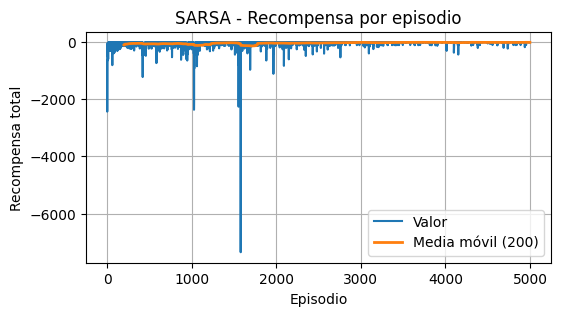

Máxima proporcion: -17


In [6]:
#@title Aciertos por número de episodios
plot_curve(
    sarsa_rewards,
    title="SARSA - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)
print(f"Máxima proporcion: {sarsa_rewards[-1]}")

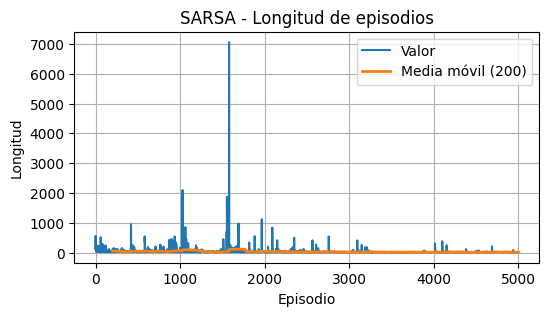

In [7]:
#@title Longitud de episodio por número de episodios
plot_curve(
    sarsa_lengths,
    title="SARSA - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

In [8]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", sarsa.Q)

Valores Q para cada estado:
 [[ -12.8545035   -10.63084427  -13.31339452  -12.90865944]
 [ -12.27247429   -9.99917345  -12.00392722  -12.31193448]
 [ -11.06787743   -9.493818    -12.22818913  -11.78167562]
 [ -11.27386942   -9.02950422  -11.81077144  -12.03290654]
 [ -10.76321064   -8.49699861  -11.12760799  -11.70026759]
 [  -9.49333426   -7.82346516  -12.40474668  -12.32015851]
 [  -8.67981983   -7.10394806   -9.49058045  -10.6955994 ]
 [  -9.73443079   -6.43995757  -11.24020958   -9.2893914 ]
 [  -9.75355417   -5.86236834  -10.38093826   -8.45807177]
 [  -6.34416345   -6.13522041   -5.12062296   -9.4163758 ]
 [  -4.77501545   -3.73595296   -4.67546752   -6.74986779]
 [  -4.81757905   -4.36338904   -2.85593119   -5.75507184]
 [ -11.37407232  -12.40508608  -13.46176834  -12.11378834]
 [ -11.4978909   -11.84167679  -13.64362808  -16.20353138]
 [ -10.3823958   -13.54680535  -13.54306733  -13.50802945]
 [ -17.97525397  -10.22815151  -16.10598566  -13.67851364]
 [  -9.13659834  -12.857133

In [9]:
# @title Política final
pi, actions, grid = sarsa.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





### **3.3 Experimentación en el escenario sin ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) de forma incremental en cada paso del episodio mediante el método de diferencias temporales (SARSA). Se aplica una política $\epsilon$-greedy sobre una política $\epsilon$-soft con un valor $\epsilon$ constante.

In [25]:
# @title Aprendizaje
sarsa = SARSA(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=False
)

sarsa_rewards, sarsa_lengths = sarsa.train(NUM_EPISODES)

Entrenando SARSA: 100%|██████████| 5000/5000 [00:27<00:00, 185.03it/s]


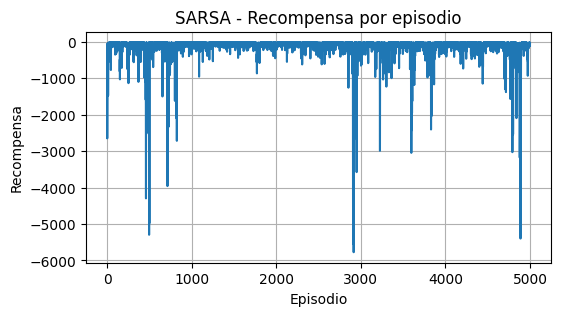

Máxima proporcion: -36


In [26]:
#@title Aciertos por número de episodios
plot_curve(
    sarsa_rewards,
    title="SARSA - Recompensa por episodio",
    ylabel="Recompensa"
)
print(f"Máxima proporcion: {sarsa_rewards[-1]}")

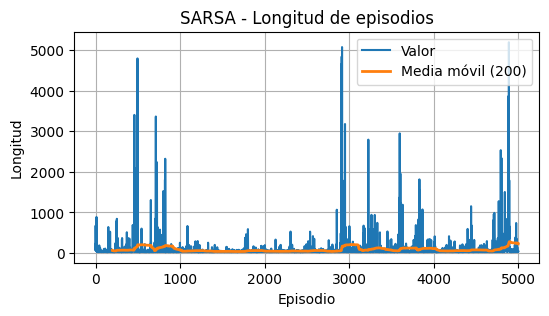

In [27]:
#@title Longitud de episodio por número de episodios
plot_curve(
    sarsa_lengths,
    title="SARSA - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

In [28]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", sarsa.Q)

Valores Q para cada estado:
 [[ -23.85790117  -20.51867081  -28.19803857  -25.31958917]
 [ -21.88372238  -20.26187579  -23.86455854  -22.87533852]
 [ -22.37508063  -20.54151818  -21.81116683  -21.23128588]
 [ -21.89908128  -20.04703194  -20.45344194  -21.92690402]
 [ -20.5865004   -19.645523    -23.05152589  -20.43469256]
 [ -23.88058268  -18.53542684  -25.10583238  -20.47794777]
 [ -18.02481097  -16.31454153  -18.50454997  -20.31081703]
 [ -16.75590499  -13.89850491  -16.40263368  -19.76598163]
 [ -14.32456336  -10.37158017  -16.9779339   -17.06552928]
 [ -10.14648937   -6.135248    -16.28771201  -15.33217092]
 [ -14.52455048   -5.55834467  -27.03822     -14.43252256]
 [  -8.57056272   -8.97458518   -4.04780445   -8.57265975]
 [ -20.12306532  -23.20545618  -26.7841537   -24.27142218]
 [ -20.77220156  -24.46776988  -23.78423211  -23.21685696]
 [ -23.46879017  -20.38879778  -72.47879715  -25.00535893]
 [ -22.31113301  -20.63901934  -24.29616378  -26.75925243]
 [ -20.8695802   -55.534197

In [29]:
# @title Política final
pi, actions, grid = sarsa.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





## **4. Fin**